In [2]:
import sys
sys.path.insert(0, r"C:\Users\setor\matplotlib_fresh")
import matplotlib.pyplot as plt

In [3]:
import pandas as pd
import re
import string
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [4]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\setor\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\setor\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\setor\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [7]:
df = pd.read_csv("iphone.csv", encoding="latin-1")
print(df.head())

  productAsin country        date  isVerified  ratingScore  \
0  B09G9BL5CP   India  11-08-2024        True            4   
1  B09G9BL5CP   India  16-08-2024        True            5   
2  B09G9BL5CP   India  14-05-2024        True            4   
3  B09G9BL5CP   India  24-06-2024        True            5   
4  B09G9BL5CP   India  18-05-2024        True            5   

               reviewTitle                                  reviewDescription  \
0               No charger  Every thing is good about iPhones, there's not...   
1          iPhone 13 256GB  It look so fabulous, I am android user switche...   
2  Flip camera option nill  I tried to flip camera while recording but no ...   
3                  Product                                       100% genuine   
4             Good product         Happy to get the iPhone 13 in Amazon offer   

                                           reviewUrl  \
0  https://www.amazon.in/gp/customer-reviews/R345...   
1  https://www.amazon.in/gp/

In [8]:
print("Shape of dataset:", df.shape)

Shape of dataset: (3062, 11)


In [9]:
print("Column names:")
print(df.columns)

Column names:
Index(['productAsin', 'country', 'date', 'isVerified', 'ratingScore',
       'reviewTitle', 'reviewDescription', 'reviewUrl', 'reviewedIn',
       'variant', 'variantAsin'],
      dtype='str')


In [10]:
print("First 5 rows:")
print(df.head())

First 5 rows:
  productAsin country        date  isVerified  ratingScore  \
0  B09G9BL5CP   India  11-08-2024        True            4   
1  B09G9BL5CP   India  16-08-2024        True            5   
2  B09G9BL5CP   India  14-05-2024        True            4   
3  B09G9BL5CP   India  24-06-2024        True            5   
4  B09G9BL5CP   India  18-05-2024        True            5   

               reviewTitle                                  reviewDescription  \
0               No charger  Every thing is good about iPhones, there's not...   
1          iPhone 13 256GB  It look so fabulous, I am android user switche...   
2  Flip camera option nill  I tried to flip camera while recording but no ...   
3                  Product                                       100% genuine   
4             Good product         Happy to get the iPhone 13 in Amazon offer   

                                           reviewUrl  \
0  https://www.amazon.in/gp/customer-reviews/R345...   
1  https://www

In [11]:
print("Last 5 rows:")
print(df.tail())

Last 5 rows:
     productAsin country        date  isVerified  ratingScore  \
3057  B09G9D8KRQ   India  11-10-2023        True            1   
3058  B09G9D8KRQ   India  14-10-2022        True            2   
3059  B09G9D8KRQ   India  24-02-2022        True            3   
3060  B09G9D8KRQ   India  16-10-2023        True            1   
3061  B09G9D8KRQ   India  11-11-2023        True            1   

                              reviewTitle  \
3057  Very bad experience with i phone 13   
3058    not happy with this apple product   
3059                           Good phone   
3060                    Battery discharge   
3061    Batter power needs to be improved   

                                      reviewDescription  \
3057  Useless phon never buy this heat n useless cam...   
3058  iam not happy with this product why because ch...   
3059                                         Good phone   
3060  While charging mobile it's getting so hot even...   
3061  Battery power is be very

In [12]:
print("Data types:")
print(df.dtypes)

Data types:
productAsin            str
country                str
date                   str
isVerified            bool
ratingScore          int64
reviewTitle            str
reviewDescription      str
reviewUrl              str
reviewedIn             str
variant                str
variantAsin            str
dtype: object


In [13]:
print("Dataset info:")
print(df.info())

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 3062 entries, 0 to 3061
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   productAsin        3062 non-null   str  
 1   country            3062 non-null   str  
 2   date               3062 non-null   str  
 3   isVerified         3062 non-null   bool 
 4   ratingScore        3062 non-null   int64
 5   reviewTitle        3062 non-null   str  
 6   reviewDescription  2976 non-null   str  
 7   reviewUrl          3046 non-null   str  
 8   reviewedIn         3062 non-null   str  
 9   variant            3062 non-null   str  
 10  variantAsin        3062 non-null   str  
dtypes: bool(1), int64(1), str(9)
memory usage: 242.3 KB
None


In [14]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
productAsin           0
country               0
date                  0
isVerified            0
ratingScore           0
reviewTitle           0
reviewDescription    86
reviewUrl            16
reviewedIn            0
variant               0
variantAsin           0
dtype: int64


In [ ]:
print("Summary statistics:")
print(df.describe())

In [15]:
stop_words = set([
    'a','an','the','and','or','is','it','this','that','to','for','of','in','on','with',
    'as','its','at','from','by','be','are','was','were','but','i','my','me','you','your',
    'so','if','they','we','he','she','them','us'
])

def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()  # convert to lowercase
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = ' '.join([word for word in text.split() if word not in stop_words])  # remove stopwords
    return text

df['review_text'] = df['reviewTitle'].fillna('') + ' ' + df['reviewDescription'].fillna('')
df['cleaned_text'] = df['review_text'].apply(clean_text)
print("\nCleaned Data (First 10 Rows):")
print(df[['review_text', 'cleaned_text']].head(10))


Cleaned Data (First 10 Rows):
                                         review_text  \
0  No charger Every thing is good about iPhones, ...   
1  iPhone 13 256GB It look so fabulous, I am andr...   
2  Flip camera option nill I tried to flip camera...   
3                               Product 100% genuine   
4  Good product Happy to get the iPhone 13 in Ama...   
5    Too smooth and effective battery life 5 star ??   
6  Apple 13 256 GB Great Product... Nothing to sa...   
7                             Good Good product ????   
8                                  Good Nice product   
9                        Excellent Excellent product   

                                        cleaned_text  
0  no charger every thing good about iphones ther...  
1  iphone 13 256gb look fabulous am android user ...  
2  flip camera option nill tried flip camera whil...  
3                                product 100 genuine  
4      good product happy get iphone 13 amazon offer  
5           too smooth

In [16]:
df = df[["ratingScore", "reviewDescription"]]
df = df.dropna()
df.head()

,ratingScore,reviewDescription
0,4,"Every thing is good about iPhones, there's not..."
1,5,"It look so fabulous, I am android user switche..."
2,4,I tried to flip camera while recording but no ...
3,5,100% genuine
4,5,Happy to get the iPhone 13 in Amazon offer


In [17]:
print("Dataset shape:", df.shape)

Dataset shape: (2976, 2)


In [18]:
def get_sentiment(rating):
    if rating >= 4:
        return "positive"
    elif rating <= 2:
        return "negative"
    else:
        return "neutral"

df["label"] = df["ratingScore"].apply(get_sentiment)
df.head()

,ratingScore,reviewDescription,label
0,4,"Every thing is good about iPhones, there's not...",positive
1,5,"It look so fabulous, I am android user switche...",positive
2,4,I tried to flip camera while recording but no ...,positive
3,5,100% genuine,positive
4,5,Happy to get the iPhone 13 in Amazon offer,positive


In [19]:
df["label"].value_counts()

label
positive    1994
negative     747
neutral      235
Name: count, dtype: int64

In [20]:
df = df[df["label"] != "neutral"].copy()
df["label"].value_counts()

label
positive    1994
negative     747
Name: count, dtype: int64

In [21]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = text.strip()

    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

df["clean_review"] = df["reviewDescription"].apply(clean_text)
df[["reviewDescription", "clean_review"]].head()

,reviewDescription,clean_review
0,"Every thing is good about iPhones, there's not...",every thing good iphones there nothing compare...
1,"It look so fabulous, I am android user switche...",look fabulous android user switched apple perf...
2,I tried to flip camera while recording but no ...,tried flip camera recording facility added pau...
3,100% genuine,genuine
4,Happy to get the iPhone 13 in Amazon offer,happy get iphone amazon offer


In [22]:
df = df[df["clean_review"].str.strip() != ""]
print("Shape after cleaning:", df.shape)

Shape after cleaning: (2714, 4)


In [23]:
X = df["clean_review"]
y = df["label"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (2171, 5000)
Testing shape: (543, 5000)


In [26]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [27]:
y_pred = model.predict(X_test_tfidf)
y_pred[:10]

array(['positive', 'positive', 'positive', 'positive', 'positive',
       'positive', 'positive', 'negative', 'positive', 'positive'],
      dtype='<U8')

In [28]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

Accuracy: 0.8029


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.98      0.28      0.44       148
    positive       0.79      1.00      0.88       395

    accuracy                           0.80       543
   macro avg       0.88      0.64      0.66       543
weighted avg       0.84      0.80      0.76       543



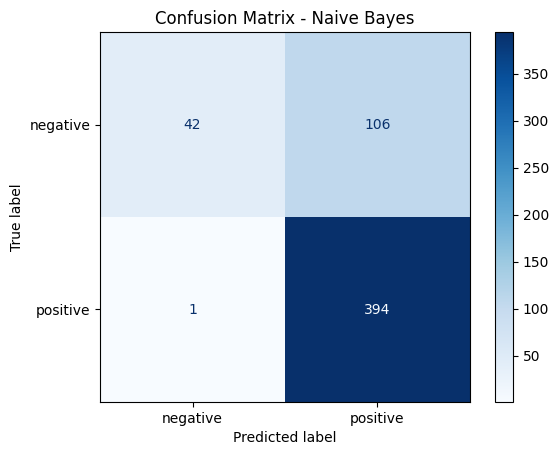

In [30]:
cm = confusion_matrix(y_test, y_pred, labels=["negative", "positive"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [31]:
print("The Naive Bayes model was able to classify reviews into positive and negative categories using TF-IDF features from cleaned review text.")
print("This shows that customer review text contains useful information for sentiment prediction.")

The Naive Bayes model was able to classify reviews into positive and negative categories using TF-IDF features from cleaned review text.
This shows that customer review text contains useful information for sentiment prediction.
